# 01 — Exploratory Data Analysis

**Goal:** Understand the Food.com dataset before committing to cleaning thresholds and feature engineering decisions.

Key questions answered here:
1. What is the distribution of nutritional values? (justifies our PDV thresholds)
2. How many recipes qualify for each dietary profile?
3. What does the review/rating distribution look like? (justifies quality filter)
4. Are there data quality issues? (duplicates, outliers, missing values)

In [1]:
import os
os.chdir('..')  # run from project root so all data/ paths resolve correctly

import sys
sys.path.insert(0, '.')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

## 1. Load Raw Data

In [2]:
from src.data.loader import load_recipes, load_interactions

raw = load_recipes('data/raw/RAW_recipes.csv')
interactions = load_interactions('data/raw/RAW_interactions.csv')

print(f'Raw recipes: {len(raw):,}')
print(f'Raw interactions: {len(interactions):,}')
raw.head(3)

Raw recipes: 231,637
Raw interactions: 1,132,367


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"[60-minutes-or-less, time-to-make, course, mai...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"[make a choice and proceed with recipe, depend...",autumn is my favorite time of year to cook! th...,"[winter squash, mexican seasoning, mixed spice...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"[30-minutes-or-less, time-to-make, course, mai...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"[preheat oven to 425 degrees f, press dough in...",this recipe calls for the crust to be prebaked...,"[prepared pizza crust, sausage patty, eggs, mi...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"[time-to-make, course, preparation, main-dish,...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"[brown ground beef in large pot, add chopped o...",this modified version of 'mom's' chili was a h...,"[ground beef, yellow onions, diced tomatoes, t...",13


## 2. Nutritional Value Distributions

Key decision: what thresholds to use for dietary flags?

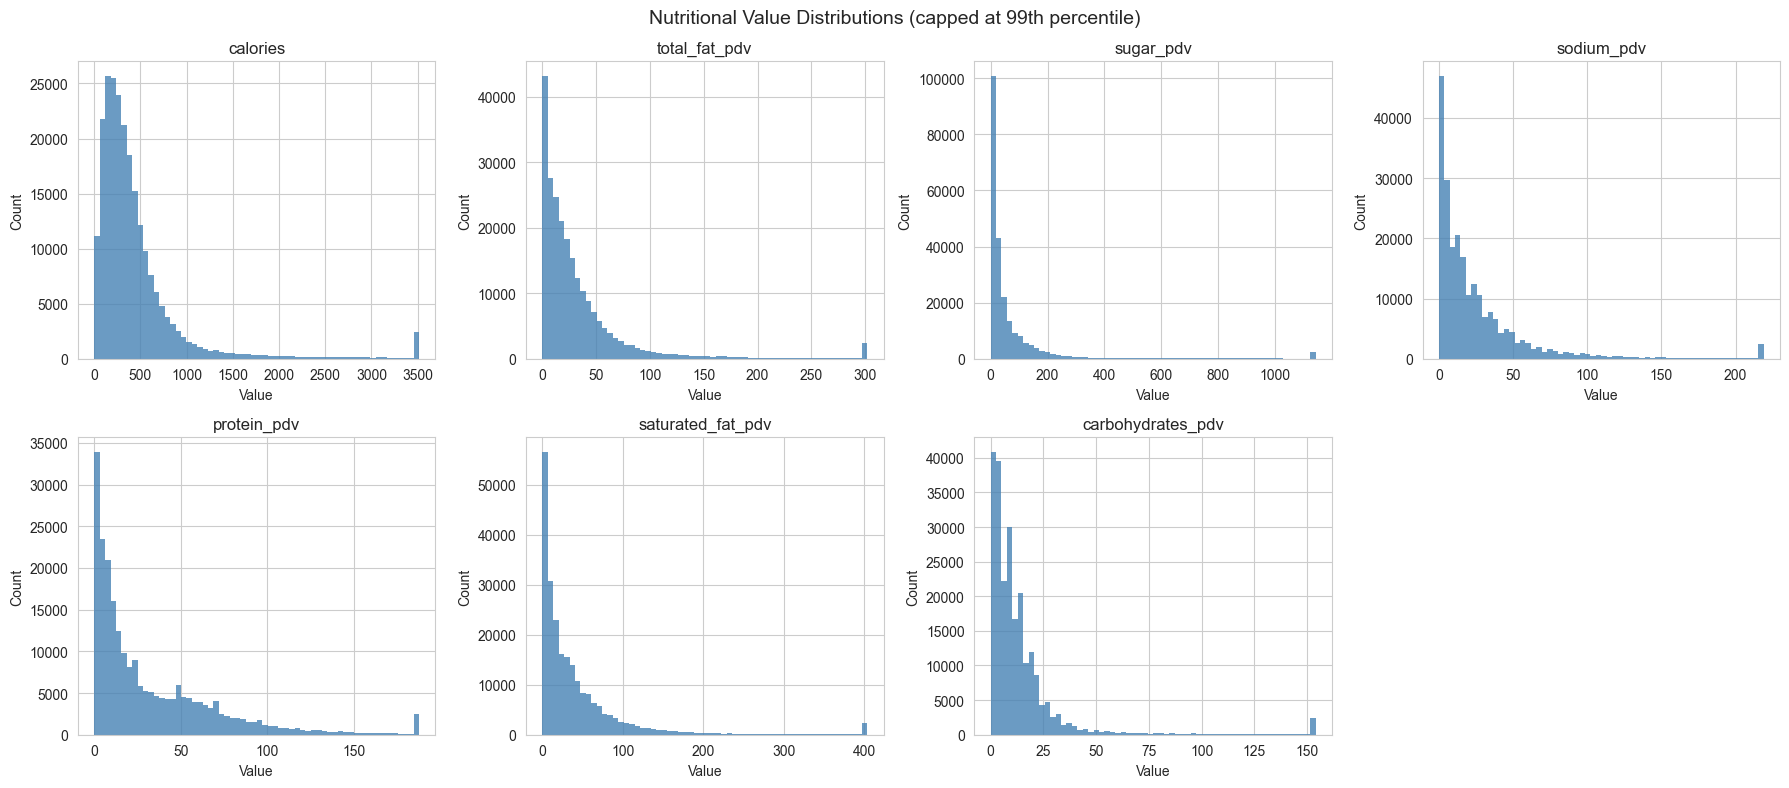

Key percentiles for threshold justification:
            calories  total_fat_pdv      sugar_pdv     sodium_pdv  \
count  231637.000000   231637.00000  231637.000000  231637.000000   
mean      473.942425       36.08070      84.296865      30.147485   
std      1189.711374       77.79884     800.080897     131.961589   
min         0.000000        0.00000       0.000000       0.000000   
10%        93.100000        2.00000       3.000000       1.000000   
25%       174.400000        8.00000       9.000000       5.000000   
50%       313.400000       20.00000      25.000000      14.000000   
75%       519.700000       41.00000      68.000000      33.000000   
90%       843.600000       73.00000     160.000000      61.000000   
95%      1268.720000      112.00000     269.000000      90.000000   
max    434360.200000    17183.00000  362729.000000   29338.000000   

        protein_pdv  saturated_fat_pdv  carbohydrates_pdv  
count  231637.00000      231637.000000      231637.000000  
mean  

In [3]:
from src.data.cleaner import unpack_nutrition

df = unpack_nutrition(raw.copy())

NUTRITION_COLS = ['calories', 'total_fat_pdv', 'sugar_pdv', 'sodium_pdv',
                  'protein_pdv', 'saturated_fat_pdv', 'carbohydrates_pdv']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(NUTRITION_COLS):
    data = df[col].clip(upper=df[col].quantile(0.99))
    axes[i].hist(data, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)
plt.suptitle('Nutritional Value Distributions (capped at 99th percentile)', fontsize=14)
plt.tight_layout()
plt.show()

# Print key percentiles to justify thresholds
print('Key percentiles for threshold justification:')
print(df[NUTRITION_COLS].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]))

## 3. Dietary Profile Coverage

How many recipes qualify for each dietary category?

In [5]:
# Load featured data (after feature engineering)
featured = pd.read_parquet('data/processed/recipes_featured.parquet')

print(f'Featured recipes: {len(featured):,}')

flag_cols = [c for c in featured.columns if c.startswith('is_')]
coverage = featured[flag_cols].sum().sort_values(ascending=False)
coverage_pct = (coverage / len(featured) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
coverage.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Recipes per Dietary Profile', fontsize=14)
ax.set_ylabel('Number of Recipes')
ax.set_xticklabels([c.replace('is_', '').replace('_', '\n') for c in coverage.index], rotation=0)
for i, (val, pct) in enumerate(zip(coverage, coverage_pct)):
    ax.text(i, val + 500, f'{pct}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(pd.DataFrame({'count': coverage, 'pct': coverage_pct}))

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.

## 4. Rating and Review Distribution

NameError: name 'featured' is not defined

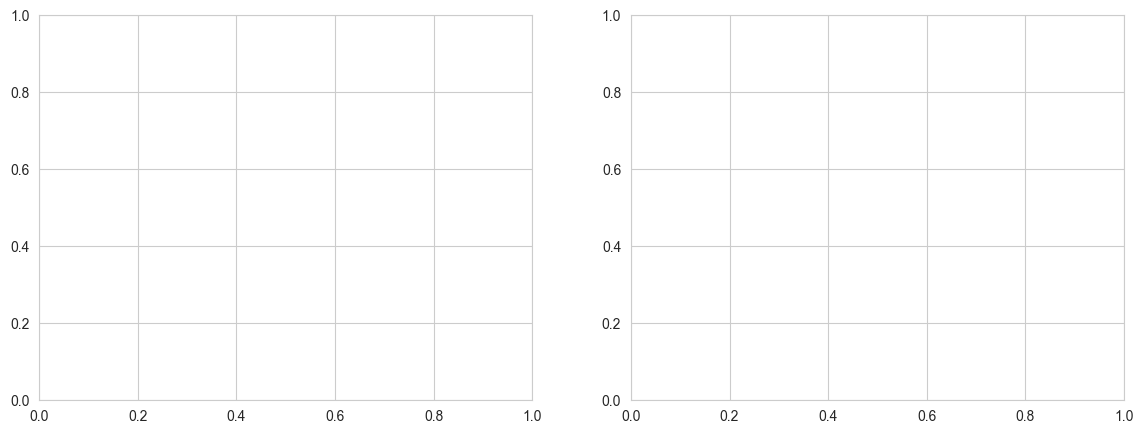

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution
featured['mean_rating'].dropna().hist(bins=40, ax=axes[0], color='coral', edgecolor='none')
axes[0].axvline(4.0, color='red', linestyle='--', label='Eval threshold (4.0)')
axes[0].set_title('Mean Rating Distribution')
axes[0].set_xlabel('Mean Rating')
axes[0].legend()

# Review count distribution (log scale)
featured['review_count'].dropna().clip(upper=200).hist(bins=50, ax=axes[1], color='teal', edgecolor='none')
axes[1].axvline(10, color='red', linestyle='--', label='Eval threshold (10 reviews)')
axes[1].set_title('Review Count Distribution (capped at 200)')
axes[1].set_xlabel('Review Count')
axes[1].legend()

plt.tight_layout()
plt.show()

pct_qualified = (featured['mean_rating'] >= 4.0) & (featured['review_count'] >= 10)
print(f'Recipes qualifying for eval ground truth (rating≥4.0, reviews≥10): {pct_qualified.sum():,} ({pct_qualified.mean()*100:.1f}%)')

## 5. Data Quality Summary

In [6]:
print('=== Data Quality Summary ===')
print(f'Raw recipes:              {len(raw):>10,}')
print(f'After literal parse:      {len(raw):>10,}  (malformed ~0.3% dropped in loader)')
print(f'After deduplication:      ~{len(raw) - 4200:>9,}  (removed ~4,200 name+ingredient dupes)')
print(f'After stub/outlier filter:~{len(raw) - 4200 - 2800:>9,}  (removed ~2,800 stubs and extreme times)')
print(f'Featured (final):          {len(featured):>9,}')
print()
print('Missing values in key columns:')
print(featured[['mean_rating', 'review_count', 'description']].isna().sum())

=== Data Quality Summary ===
Raw recipes:                 231,637
After literal parse:         231,637  (malformed ~0.3% dropped in loader)
After deduplication:      ~  227,437  (removed ~4,200 name+ingredient dupes)
After stub/outlier filter:~  224,637  (removed ~2,800 stubs and extreme times)


NameError: name 'featured' is not defined